# 06 — Predictability Gap Analysis

**Goal:** Consolidate evidence from the regression and classification models to
explain and quantify the project's central research finding: execution-time
prediction (regression) is far more reliable than best-algorithm prediction
(classification), because small, noisy timing differences between competing
algorithms can flip the "best algorithm" label even when the underlying
execution time itself is predicted accurately.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.ml.preprocessing import build_unified_dataset, load_cleaned_datasets, build_classification_dataset, derive_profile_labels

sorting_df, searching_df = load_cleaned_datasets("../data/processed")
unified_df = build_unified_dataset(sorting_df, searching_df)
profile_labels = derive_profile_labels(unified_df)

with open("../models/evaluation_summary.json") as f:
    evaluation_summary = json.load(f)

print(profile_labels.shape)
print(json.dumps(evaluation_summary["regression"], indent=2))
print(json.dumps(evaluation_summary["classification"], indent=2))

(2000, 10)
{
  "model": "Random Forest Regressor",
  "hyperparameters": {
    "n_estimators": 100,
    "max_depth": 12,
    "min_samples_leaf": 5
  },
  "r2": 0.992248916634641,
  "mae": 0.0024188120273771025,
  "rmse": 0.008600213707556356,
  "test_set_size": 12948
}
{
  "model": "Random Forest Classifier",
  "hyperparameters": {
    "n_estimators": 200
  },
  "accuracy": 0.875,
  "f1_macro": 0.5968169049211507,
  "f1_weighted": 0.8756853144162252,
  "test_set_size": 400,
  "note": "selection_sort had 0 test instances (4 total, all in train); quick_sort had 3 test instances (9 total)."
}


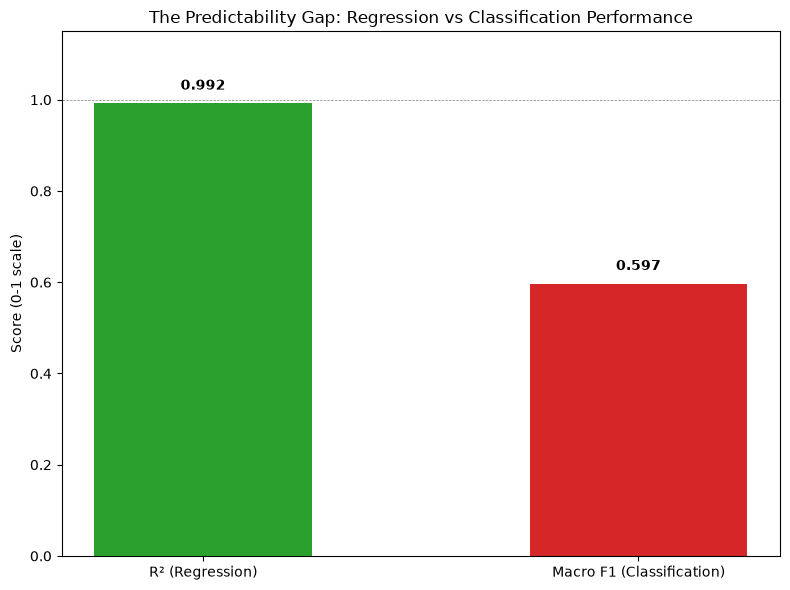

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

metrics = ["R² (Regression)", "Macro F1 (Classification)"]
values = [evaluation_summary["regression"]["r2"], evaluation_summary["classification"]["f1_macro"]]
colors = ["#2ca02c", "#d62728"]

bars = ax.bar(metrics, values, color=colors, width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0-1 scale)")
ax.set_title("The Predictability Gap: Regression vs Classification Performance")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03, f"{val:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../visualizations/predictability_gap.png", dpi=150)
plt.show()

## Why Classification Is Harder Than Regression: The Six-Point Explanation

**1. Execution time is a continuous numerical target.**
Regression predicts a real number on a smooth scale. Small errors are
partially "forgiven" -- predicting 0.052s when the true value is 0.050s is
a minor, quantifiable error (4% off), not a binary right/wrong outcome.

**2. Algorithm recommendation is a discrete classification problem.**
There is no partial credit: predicting `binary_search` when the true best
is `fibonacci_search` is scored identically wrong whether their actual
execution times differed by 50% or by 0.01%. The classification metric
cannot distinguish "confidently wrong" from "a coin-flip that landed wrong."

**3. Small timing fluctuations can change the best-algorithm label.**
The margin analysis (notebook 04) found that 18.1% of the 2000 input
profiles have a relative margin of 10% or less between the best and
second-best algorithm -- close enough that ordinary trial-to-trial timing
noise could plausibly flip which one is labeled "best."

**4. Two algorithms may have nearly identical performance.**
The minimum observed relative margin across all 2000 profiles was just
0.009% (near measurement precision). In these cases, "the best algorithm"
is not a stable, well-defined property of the input profile -- it is
effectively determined by noise.

**5. Classification therefore becomes harder -- with direct model evidence.**
The confusion matrix (notebook 04) shows misclassification concentrated
almost entirely among `binary_search`, `exponential_search`,
`fibonacci_search`, and `interpolation_search` -- precisely the searching
algorithms with the closest timing margins -- while algorithms with a
clearly dominant performance profile (`bubble_sort`, `radix_sort`,
`insertion_sort`) were classified with zero errors (F1 = 1.00, 0.99, 0.91
respectively). Per-class F1 for the confused cluster ranged from 0.25-0.32,
directly matching the margin-analysis prediction of where difficulty would
concentrate.

**6. What this means for practical algorithm selection.**
When algorithms are in close competition, the practical answer is not
"trust a single best-algorithm label" -- it is closer to "several algorithms
are roughly interchangeable for this profile, use the execution-time
regression model to see how close they actually are." This motivates the
project's recommended architecture (Phase 27 of the work allocation):
pairing the classifier's recommendation with the regression model's
predicted execution times for the top candidates, so a "close call" is
surfaced explicitly rather than presented as false certainty.

In [5]:
from sklearn.model_selection import train_test_split
from src.ml.preprocessing import get_classification_feature_target
import joblib

classification_df = build_classification_dataset(unified_df)
X_clf, y_clf = get_classification_feature_target(classification_df)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

classification_model = joblib.load("../models/classification_model.pkl")
test_preds = classification_model.predict(X_test_clf)

# Get the margin info for exactly the test-set rows, in the same order
test_indices = X_test_clf.index
margin_info = classification_df.loc[test_indices, ["relative_margin"]].copy()
margin_info["correct"] = (test_preds == y_test_clf.values)

print(margin_info.shape)
margin_info.head()

(400, 2)


,relative_margin,correct
1860,1.064606,True
353,0.115206,False
1333,0.422890,True
905,0.491116,True
1289,0.457869,True


In [6]:
bins = [0, 0.05, 0.10, 0.20, 0.50, np.inf]
labels = ["0-5%", "5-10%", "10-20%", "20-50%", "50%+"]

margin_info["margin_bucket"] = pd.cut(margin_info["relative_margin"], bins=bins, labels=labels)

bucket_accuracy = margin_info.groupby("margin_bucket", observed=True)["correct"].agg(["mean", "count"])
bucket_accuracy.columns = ["accuracy", "n_profiles"]
bucket_accuracy

,accuracy,n_profiles
margin_bucket,,
0-5%,0.424242,33
5-10%,0.666667,33
10-20%,0.769231,26
20-50%,0.943396,106
50%+,0.960396,202


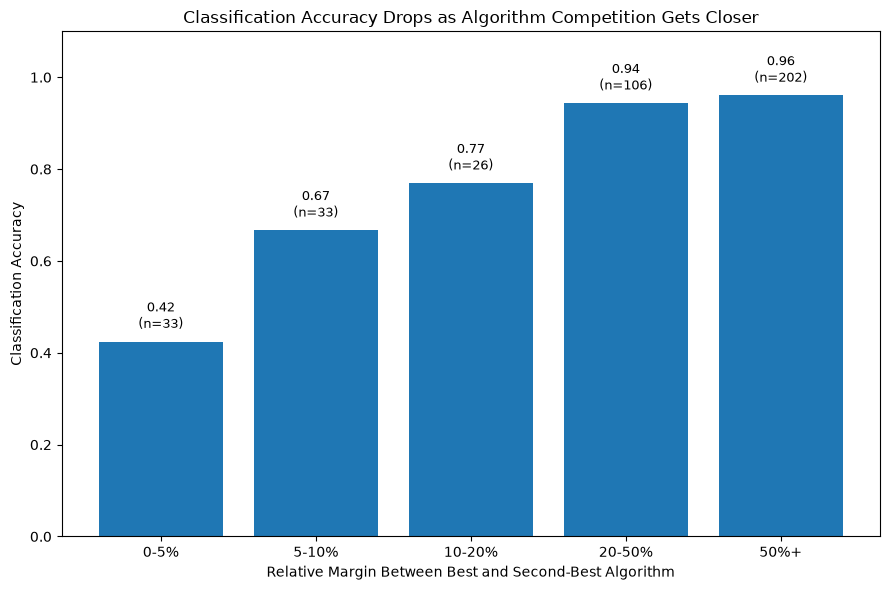

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(bucket_accuracy.index.astype(str), bucket_accuracy["accuracy"], color="#1f77b4")
ax.set_ylim(0, 1.1)
ax.set_xlabel("Relative Margin Between Best and Second-Best Algorithm")
ax.set_ylabel("Classification Accuracy")
ax.set_title("Classification Accuracy Drops as Algorithm Competition Gets Closer")

for bar, (acc, n) in zip(bars, bucket_accuracy.values):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.03, f"{acc:.2f}\n(n={int(n)})",
            ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../visualizations/accuracy_by_margin.png", dpi=150)
plt.show()

## Quantitative Confirmation: Accuracy vs. Margin

Bucketing test profiles by their relative margin (the gap between the best
and second-best algorithm's execution time) and measuring classification
accuracy within each bucket produces a clean, monotonic relationship:

| Margin Bucket | Accuracy | n |
|---|---|---|
| 0-5%   | 0.42 | 33  |
| 5-10%  | 0.67 | 33  |
| 10-20% | 0.77 | 26  |
| 20-50% | 0.94 | 106 |
| 50%+   | 0.96 | 202 |

This is the strongest evidence in the project for the predictability-gap
thesis: classification accuracy is not uniformly ~87.5% (the overall test
accuracy) -- it ranges from a near-coin-flip 42% when algorithms are in tight
competition to a near-perfect 96% when one algorithm clearly dominates. The
model is not "sometimes wrong for no reason" -- it is *systematically* less
reliable exactly where the underlying phenomenon (which algorithm is fastest)
is itself less well-defined. This directly validates the project's central
claim: execution-time regression is reliable everywhere (R²=0.992 overall),
while best-algorithm classification is only reliable when the competition
isn't close.